In [1]:
from pathlib import Path
import json
import random
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader


DATASET_ROOT = Path.cwd() / "Dataset_Normalzied"

TACHO_TRAIN_DIR = DATASET_ROOT / "tacho" / "train"
TACHO_TEST_DIR = DATASET_ROOT / "tacho" / "test"

NON_TACHO_TRAIN_DIR = DATASET_ROOT / "non_tacho" / "train"
NON_TACHO_TEST_DIR = DATASET_ROOT / "non_tacho" / "test"

BATCH_SIZE = 32
NUM_WORKERS = 0

EPOCHS = 500
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

RANDOM_SEED = 42

RUN_TRAINING = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Device:", DEVICE)
print("Dataset root:", DATASET_ROOT)
print("Używany interpreter:", sys.executable)
print("Wersja biblioteki torch:", torch.__version__)
print("Czy akceleracja GPU działa:", torch.cuda.is_available())


Device: cuda
Dataset root: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied
Używany interpreter: D:\Projects\GitHub\Wywazanie\.venv\Scripts\python.exe
Wersja biblioteki torch: 2.5.1+cu121
Czy akceleracja GPU działa: True


In [2]:
def natural_key(path):
    return [int(x) if x.isdigit() else x.lower() for x in re.split(r"(\d+)", path.name)]


def list_npy_files(folder):
    folder = Path(folder)

    if not folder.exists():
        raise FileNotFoundError(f"Folder does not exist: {folder}")

    files = sorted(folder.glob("*.npy"), key=natural_key)

    if not files:
        raise FileNotFoundError(f"No .npy files found in: {folder}")

    return files


def load_datapoint(path):
    return np.load(path, allow_pickle=True).item()


def is_missing(value):
    if value is None:
        return True

    if isinstance(value, str) and value.lower() in {"none", "nan", "unknown", ""}:
        return True

    try:
        return bool(np.isnan(value))
    except TypeError:
        return False


def parse_label_from_filename(path, field_name):
    pattern = rf"{field_name}_(?P<value>[^_]+)"
    match = re.search(pattern, path.stem)

    if not match:
        return None

    value = match.group("value")

    if is_missing(value):
        return None

    try:
        return float(value)
    except ValueError:
        return None


def extract_regression_target(payload, target_name, path=None):
    metadata = payload.get("metadata", {})

    if target_name == "actual_angle_sin_cos":
        target = payload.get("y_actual_phase_sin_cos", None)
        if target is not None:
            return np.asarray(target, dtype=np.float32)
        return None

    if target_name == "actual_amp":
        value = payload.get("y_actual_amp", None)
        if value is not None:
            return np.array([float(value)], dtype=np.float32)
        return None

    if target_name == "angle_sin_cos":
        target = payload.get("y_angle_sin_cos", None)

        if target is not None:
            target = np.asarray(target, dtype=np.float32)

            if target.shape == (2,) and np.all(np.isfinite(target)):
                return target

        angle_sin = metadata.get("angle_sin", None)
        angle_cos = metadata.get("angle_cos", None)

        if not is_missing(angle_sin) and not is_missing(angle_cos):
            return np.array([angle_sin, angle_cos], dtype=np.float32)

        return None

    if target_name in {"imbalance", "mass"}:
        value = payload.get("y_imbalance_value", None)

        if is_missing(value):
            value = payload.get("y_location", None)

        if is_missing(value):
            value = metadata.get("location_label", None)

        if is_missing(value) and path is not None:
            value = parse_label_from_filename(path, "Imbalance")

        if is_missing(value):
            return None

        return np.array([float(value)], dtype=np.float32)

    raise ValueError(f"Unknown target_name: {target_name!r}")


class SpectrogramRegressionDataset(Dataset):
    """
    Loads individual normalized .npy datapoints for regression.

    target_name:
    - "angle_sin_cos" -> target shape [2]
    - "imbalance"     -> target shape [1]
    """

    def __init__(self, folder, target_name, skip_missing_labels=True):
        self.folder = Path(folder)
        self.target_name = target_name
        self.skip_missing_labels = skip_missing_labels

        all_files = list_npy_files(self.folder)

        valid_files = []
        targets = []
        skipped_rows = []

        for path in all_files:
            payload = load_datapoint(path)
            target = extract_regression_target(payload, target_name, path=path)

            if target is None:
                metadata = payload.get("metadata", {})

                skipped_rows.append({
                    "file": path.name,
                    "source_npy": metadata.get("source_npy", None),
                    "angle": metadata.get("angle", None),
                    "angle_sin": metadata.get("angle_sin", None),
                    "angle_cos": metadata.get("angle_cos", None),
                    "y_imbalance_value": payload.get("y_imbalance_value", None),
                    "location_label": metadata.get("location_label", None),
                    "target_name": target_name,
                })

                if skip_missing_labels:
                    continue

                raise ValueError(
                    f"Missing target {target_name!r} in {path.name}. Metadata: {metadata}"
                )

            valid_files.append(path)
            targets.append(target.astype(np.float32))

        self.skipped_labels = pd.DataFrame(skipped_rows)
        self.all_files_count = len(all_files)
        self.files = valid_files
        self.targets = targets

        if not self.files:
            raise ValueError(
                f"No valid labelled files found in {self.folder} for target {target_name!r}. "
                f"Skipped {len(skipped_rows)} files."
            )

        first_payload = load_datapoint(self.files[0])
        self.component_names = list(first_payload["component_names"])
        self.frequency_hz = first_payload["frequency_hz"].astype(np.float32)

        first_X = first_payload["X"].astype(np.float32)
        self.input_shape = first_X.shape
        self.in_channels = first_X.shape[0]
        self.target_dim = int(self.targets[0].shape[0])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        payload = load_datapoint(self.files[idx])

        X = payload["X"].astype(np.float32)
        y = self.targets[idx].astype(np.float32)

        return torch.from_numpy(X), torch.from_numpy(y)

    def get_payload(self, idx):
        return load_datapoint(self.files[idx])

    def get_target(self, idx):
        return self.targets[idx]

    def summary(self, name):
        print("=" * 80)
        print(name)
        print("=" * 80)
        print("Folder:", self.folder)
        print("All files:", self.all_files_count)
        print("Used labelled files:", len(self.files))
        print("Skipped unlabelled files:", len(self.skipped_labels))
        print("Input shape [C, F, T]:", self.input_shape)
        print("Target dim:", self.target_dim)
        print("Components:", self.component_names)

        targets = np.stack(self.targets, axis=0)
        print("Target mean:", targets.mean(axis=0))
        print("Target std: ", targets.std(axis=0))
        print("Target min: ", targets.min(axis=0))
        print("Target max: ", targets.max(axis=0))

        if len(self.skipped_labels):
            print()
            print("Skipped examples:")
            display(self.skipped_labels.head(20))

        print()


In [3]:
tacho_train_ds = SpectrogramRegressionDataset(
    TACHO_TRAIN_DIR,
    target_name="actual_angle_sin_cos",
    skip_missing_labels=True,
)

tacho_test_ds = SpectrogramRegressionDataset(
    TACHO_TEST_DIR,
    target_name="actual_angle_sin_cos",
    skip_missing_labels=True,
)

non_tacho_train_ds = SpectrogramRegressionDataset(
    NON_TACHO_TRAIN_DIR,
    target_name="actual_amp",
    skip_missing_labels=True,
)

non_tacho_test_ds = SpectrogramRegressionDataset(
    NON_TACHO_TEST_DIR,
    target_name="actual_amp",
    skip_missing_labels=True,
)

tacho_train_ds.summary("Tachometer train dataset | target = angle sin/cos")
tacho_test_ds.summary("Tachometer test dataset | target = angle sin/cos")

non_tacho_train_ds.summary("Non-tachometer train dataset | target = imbalance/mass value")
non_tacho_test_ds.summary("Non-tachometer test dataset | target = imbalance/mass value")


tacho_train_loader = DataLoader(
    tacho_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

tacho_test_loader = DataLoader(
    tacho_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

non_tacho_train_loader = DataLoader(
    non_tacho_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

non_tacho_test_loader = DataLoader(
    non_tacho_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


Tachometer train dataset | target = angle sin/cos
Folder: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied\tacho\train
All files: 703
Used labelled files: 703
Skipped unlabelled files: 0
Input shape [C, F, T]: (9, 5000, 3)
Target dim: 2
Components: ['ACXXX_SN1 [g] | amplitude_db', 'ACXXX_SN1 [g] | phase_sin', 'ACXXX_SN1 [g] | phase_cos', 'ACXXX_SN2 [g] | amplitude_db', 'ACXXX_SN2 [g] | phase_sin', 'ACXXX_SN2 [g] | phase_cos', 'Tacho_Ch8 [Hz] | amplitude_db', 'Tacho_Ch8 [Hz] | phase_sin', 'Tacho_Ch8 [Hz] | phase_cos']
Target mean: [-0.05841598 -0.00915532]
Target std:  [0.71987987 0.6915755 ]
Target min:  [-0.99999994 -0.9999953 ]
Target max:  [0.9999877  0.99999744]

Tachometer test dataset | target = angle sin/cos
Folder: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied\tacho\test
All files: 179
Used labelled files: 179
Skipped unlabelled files: 0
Input shape [C, F, T]: (9, 5000, 3)
Target dim: 2
Components: ['ACXXX_SN1 [g] | amplitude_db', 'ACXXX_SN1 [g] | phase_sin',

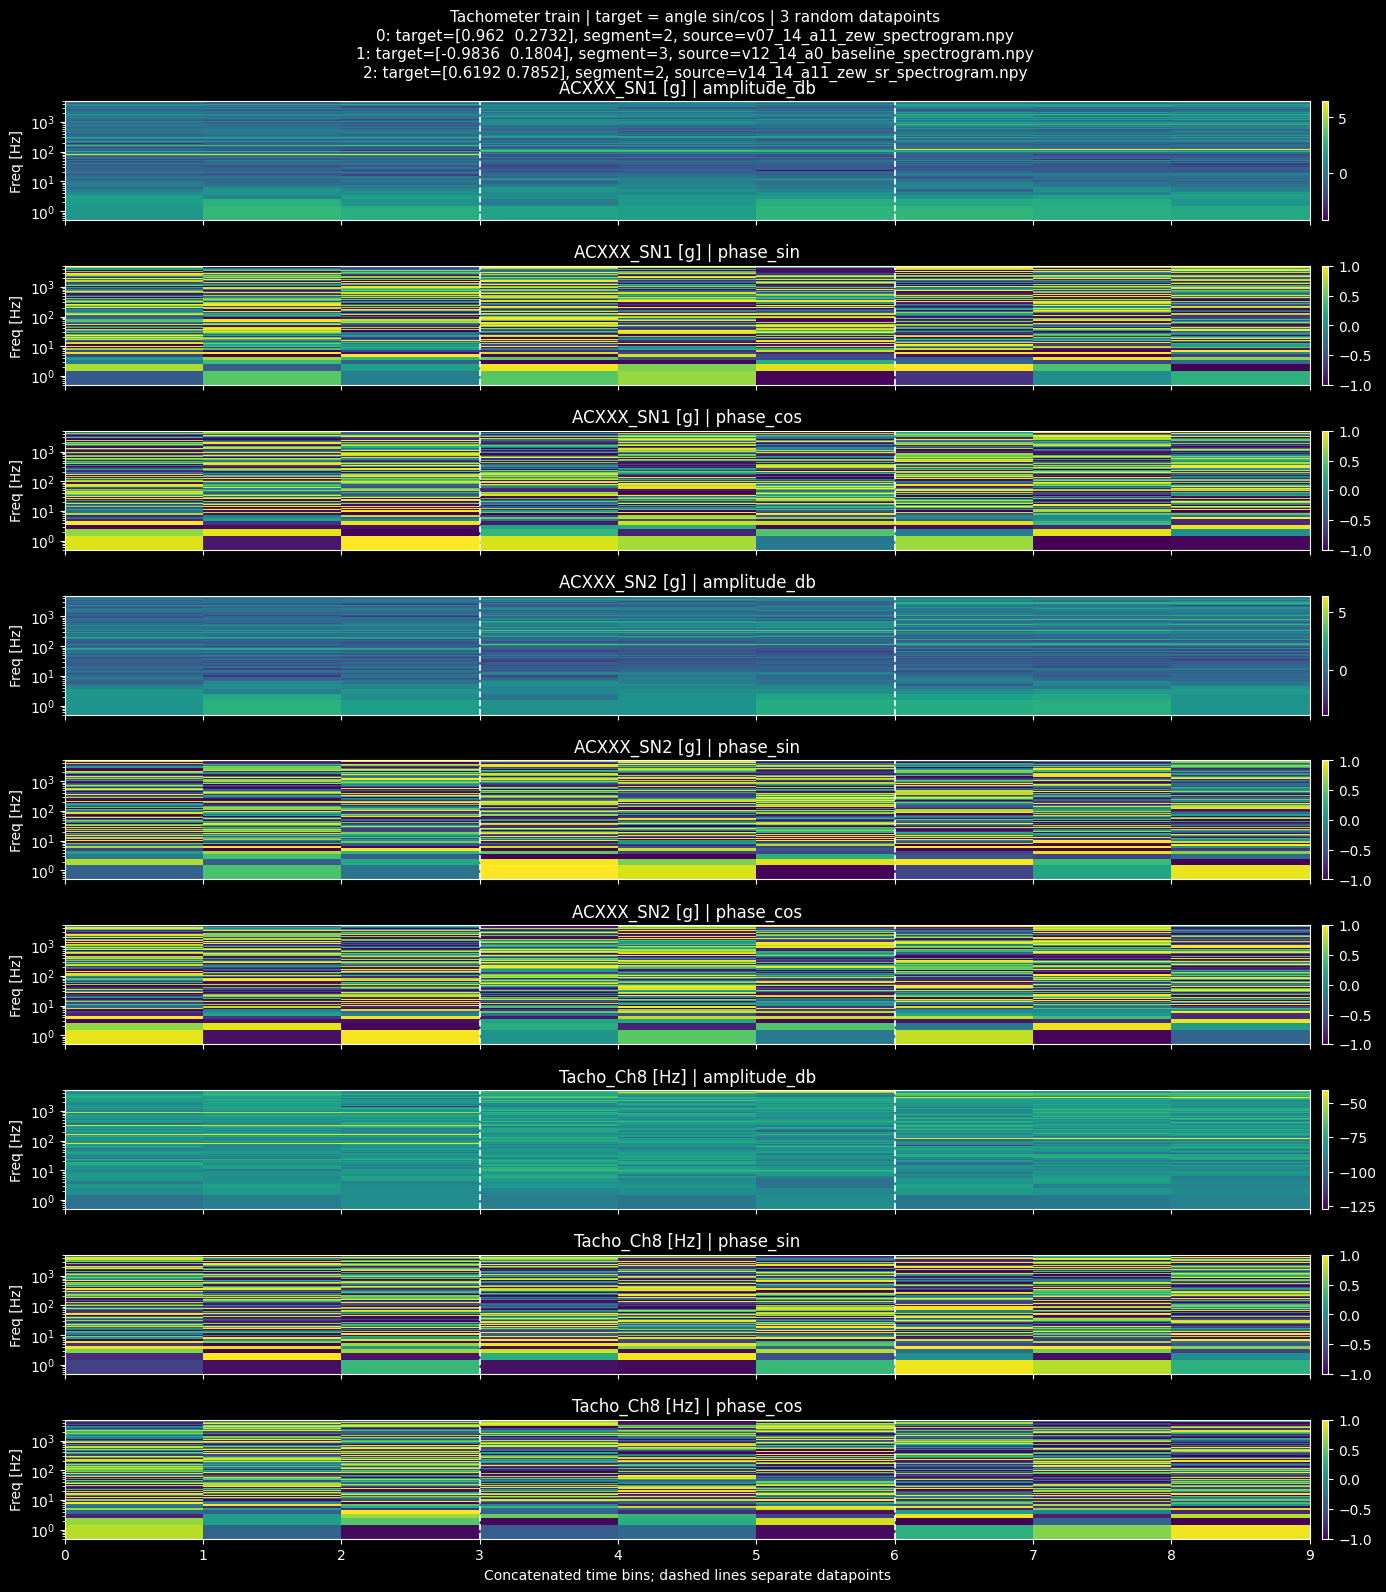

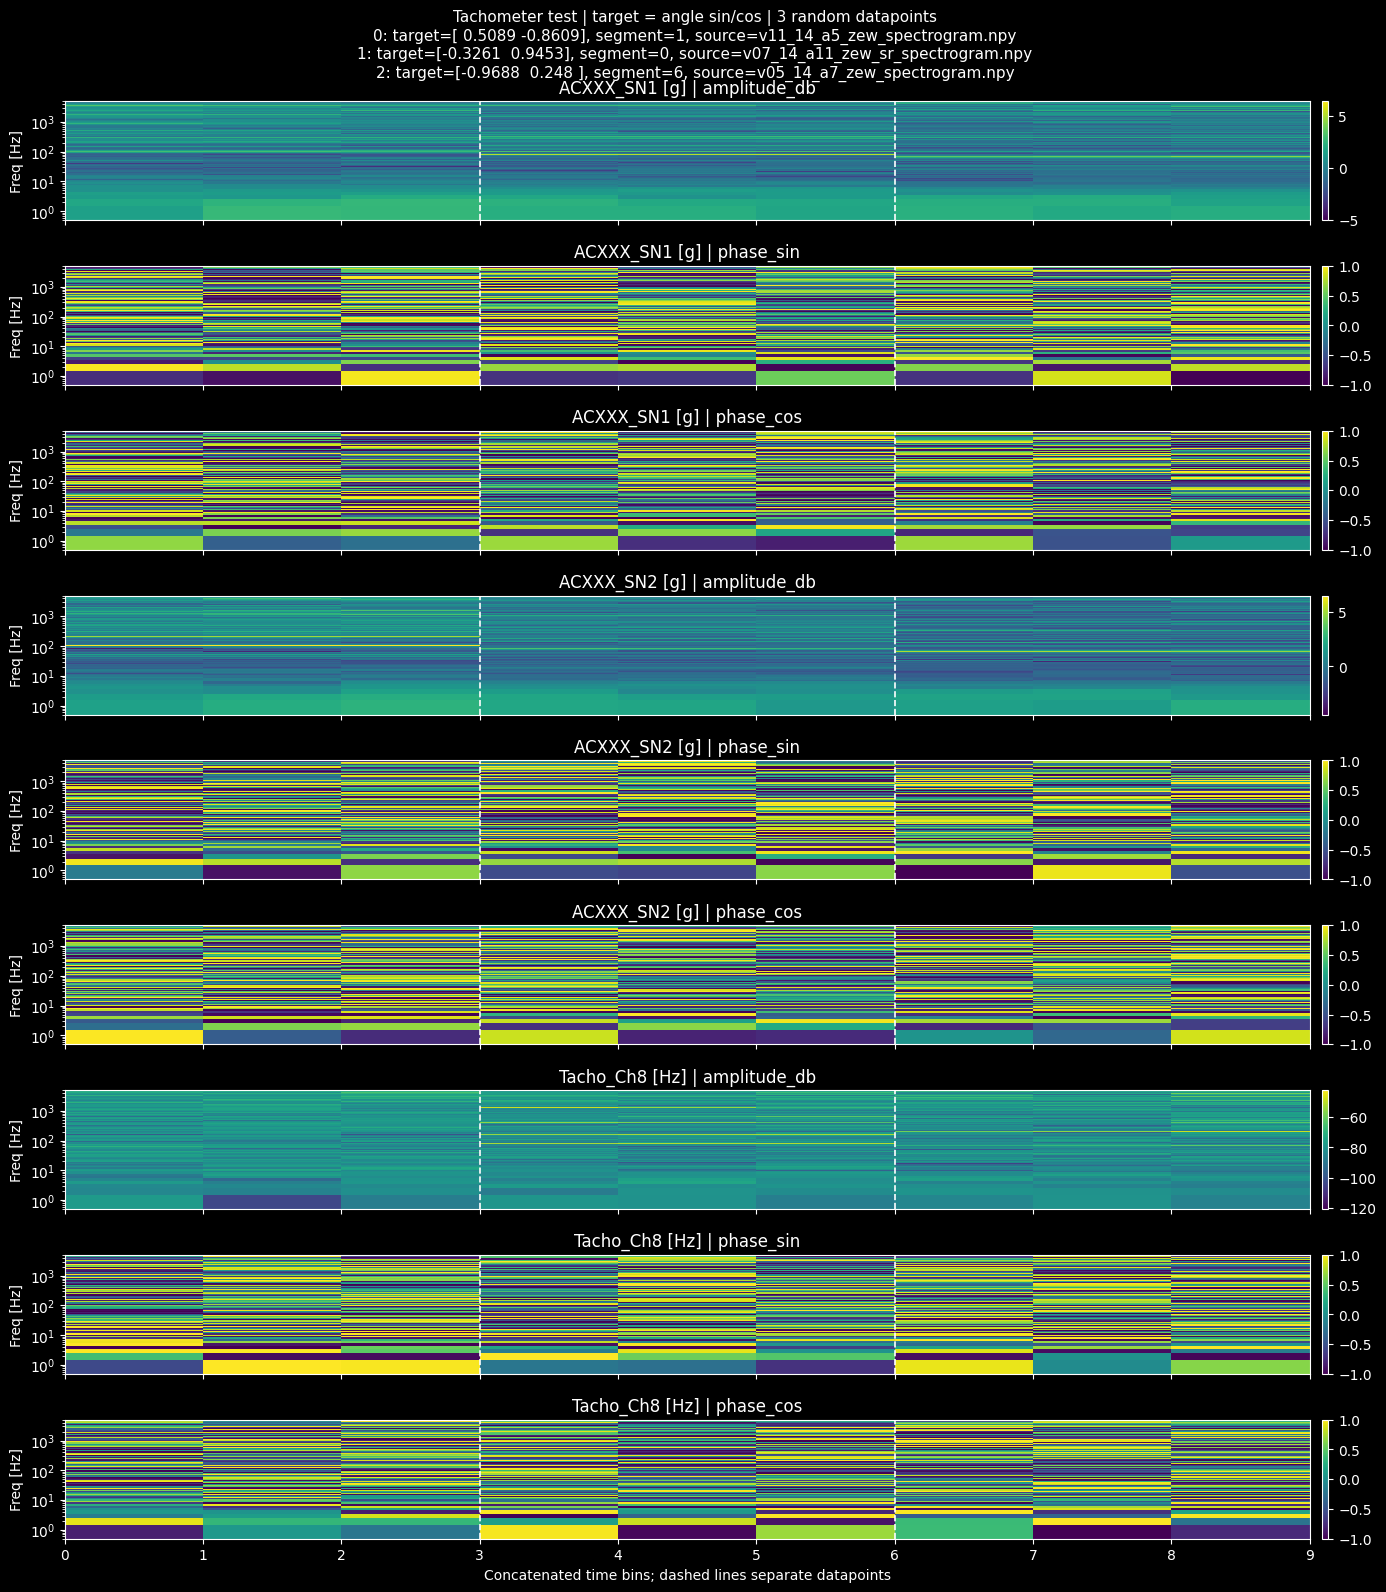

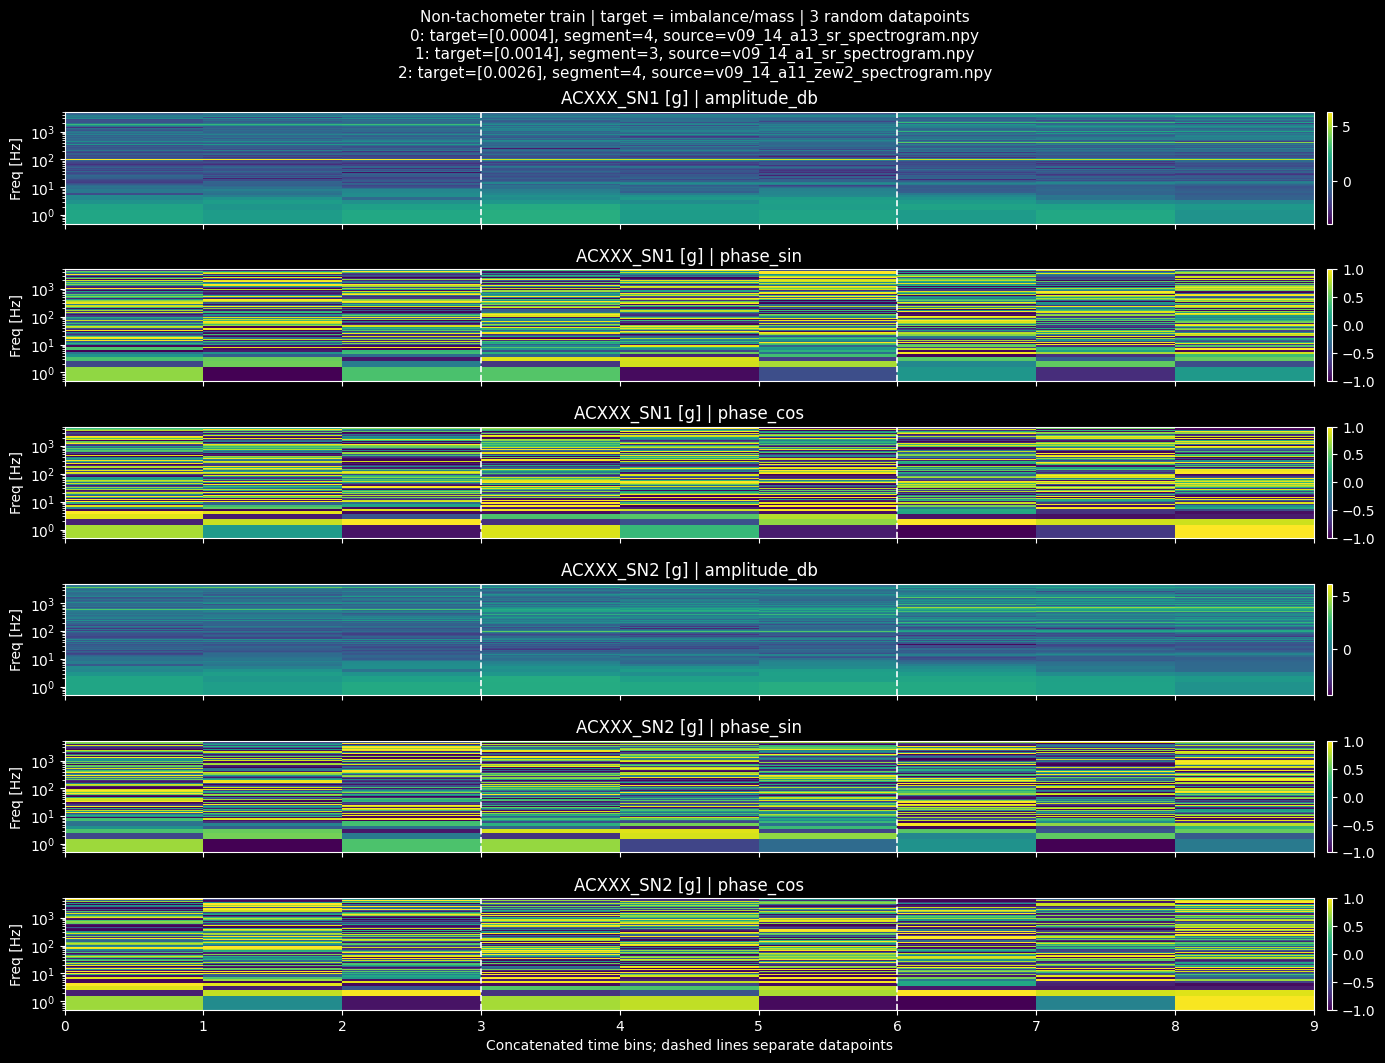

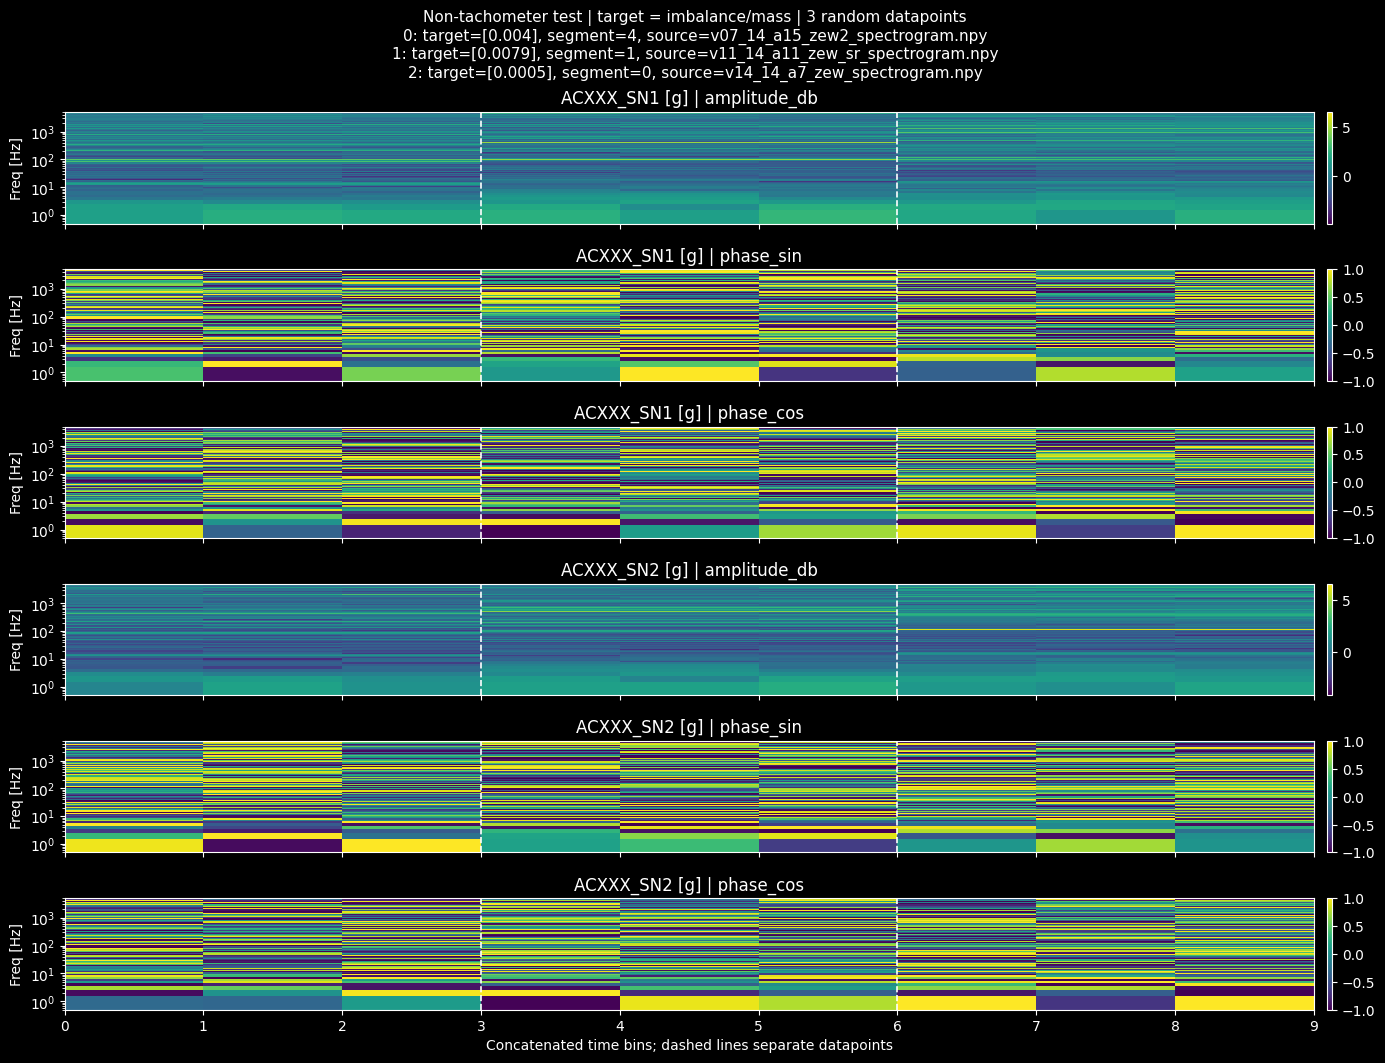

In [4]:
def frequency_edges_from_centers(frequency_hz):
    frequency_hz = np.asarray(frequency_hz, dtype=np.float64)

    if len(frequency_hz) < 2:
        raise ValueError("Need at least two frequency bins for plotting.")

    edges = np.empty(len(frequency_hz) + 1, dtype=np.float64)
    edges[1:-1] = 0.5 * (frequency_hz[:-1] + frequency_hz[1:])
    edges[0] = max(1e-9, frequency_hz[0] - 0.5 * (frequency_hz[1] - frequency_hz[0]))
    edges[-1] = frequency_hz[-1] + 0.5 * (frequency_hz[-1] - frequency_hz[-2])
    edges[edges <= 0] = 1e-9

    return edges


def plot_three_random_datapoints(dataset, title, n=3, seed=RANDOM_SEED):
    if len(dataset) == 0:
        print(f"No data to plot: {title}")
        return

    rng = np.random.default_rng(seed)
    n = min(n, len(dataset))
    indices = rng.choice(len(dataset), size=n, replace=False)

    payloads = [dataset.get_payload(int(idx)) for idx in indices]
    X_list = [payload["X"].astype(np.float32) for payload in payloads]

    X_concat = np.concatenate(X_list, axis=2)  # [C, F, n * T]
    n_channels, n_freq, total_time_bins = X_concat.shape
    segment_time_bins = X_list[0].shape[2]

    frequency_hz = payloads[0]["frequency_hz"].astype(np.float32)
    f_edges = frequency_edges_from_centers(frequency_hz)
    x_edges = np.arange(total_time_bins + 1)

    component_names = payloads[0]["component_names"]

    fig, axes = plt.subplots(
        n_channels,
        1,
        figsize=(14, max(3, 1.8 * n_channels)),
        sharex=True,
        squeeze=False,
    )

    for channel_idx in range(n_channels):
        ax = axes[channel_idx, 0]
        component_name = component_names[channel_idx]

        kwargs = {}

        if component_name.endswith("phase_sin") or component_name.endswith("phase_cos"):
            kwargs["vmin"], kwargs["vmax"] = -1.0, 1.0

        im = ax.pcolormesh(
            x_edges,
            f_edges,
            X_concat[channel_idx],
            shading="auto",
            **kwargs,
        )

        ax.set_yscale("log")
        ax.set_ylabel("Freq [Hz]")
        ax.set_title(component_name)

        for boundary_idx in range(1, n):
            ax.axvline(
                boundary_idx * segment_time_bins,
                linestyle="--",
                linewidth=1.2,
            )

        fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)

    labels = []

    for i, payload in enumerate(payloads):
        metadata = payload["metadata"]
        source = metadata.get("source_npy", "unknown")
        segment = metadata.get("segment_idx", "unknown")
        target = dataset.get_target(int(indices[i]))

        labels.append(
            f"{i}: target={np.round(target, 4)}, segment={segment}, source={source}"
        )

    axes[-1, 0].set_xlabel("Concatenated time bins; dashed lines separate datapoints")

    fig.suptitle(title + "\n" + "\n".join(labels), fontsize=11)
    plt.tight_layout()
    plt.show()


plot_three_random_datapoints(
    tacho_train_ds,
    "Tachometer train | target = angle sin/cos | 3 random datapoints",
    seed=RANDOM_SEED,
)

plot_three_random_datapoints(
    tacho_test_ds,
    "Tachometer test | target = angle sin/cos | 3 random datapoints",
    seed=RANDOM_SEED + 1,
)

plot_three_random_datapoints(
    non_tacho_train_ds,
    "Non-tachometer train | target = imbalance/mass | 3 random datapoints",
    seed=RANDOM_SEED + 2,
)

plot_three_random_datapoints(
    non_tacho_test_ds,
    "Non-tachometer test | target = imbalance/mass | 3 random datapoints",
    seed=RANDOM_SEED + 3,
)


In [5]:
# class SpectrogramCNNRegressor(nn.Module):  #small
#     """
#     Smaller CNN for spectrogram regression.

#     Good for quick tests and lower overfitting risk.

#     Input:
#         [batch, channels, frequency_bins, time_bins]
#     """

#     def __init__(self, in_channels, output_dim, dropout=0.20):
#         super().__init__()

#         self.features = nn.Sequential(
#             nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
#             nn.BatchNorm2d(16),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=(2, 1)),

#             nn.Conv2d(16, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=(2, 1)),

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True),
#         )

#         self.pool = nn.AdaptiveAvgPool2d((1, 1))

#         self.regressor = nn.Sequential(
#             nn.Flatten(),
#             nn.Dropout(dropout),
#             nn.Linear(64, output_dim),
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.pool(x)
#         x = self.regressor(x)
#         return x




In [6]:
class SpectrogramCNNRegressor(nn.Module): # large
    """
    Larger CNN for spectrogram regression.

    Better capacity, but more overfitting risk.
    """

    def __init__(self, in_channels, output_dim, dropout=0.35):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, output_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x

In [7]:
# class SpectrogramCNNRegressor(nn.Module):
#     """
#     Generic CNN for spectrogram regression.

#     Input:
#         [batch, channels, frequency_bins, time_bins]

#     Time dimension is small, e.g. 3 bins, so pooling is mainly over frequency.
#     """

#     def __init__(self, in_channels, output_dim, dropout=0.25):
#         super().__init__()

#         self.features = nn.Sequential(
#             nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=(2, 1)),

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=(2, 1)),

#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=(2, 1)),

#             nn.Conv2d(128, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),
#         )

#         self.pool = nn.AdaptiveAvgPool2d((1, 1))

#         self.regressor = nn.Sequential(
#             nn.Flatten(),
#             nn.Dropout(dropout),
#             nn.Linear(128, output_dim),
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.pool(x)
#         x = self.regressor(x)
#         return x

In [8]:
class TachoAngleSinCosCNN(nn.Module):
    """
    Model 1:
    Tachometer dataset -> angle regression as [sin(angle), cos(angle)].
    """

    def __init__(self, in_channels):
        super().__init__()
        self.model = SpectrogramCNNRegressor(
            in_channels=in_channels,
            output_dim=2,
        )

    def forward(self, x):
        return self.model(x)


class NonTachoImbalanceCNN(nn.Module):
    """
    Model 2:
    Non-tachometer dataset -> imbalance/mass value regression.
    """

    def __init__(self, in_channels):
        super().__init__()
        self.model = SpectrogramCNNRegressor(
            in_channels=in_channels,
            output_dim=1,
        )

    def forward(self, x):
        return self.model(x)


tacho_model = TachoAngleSinCosCNN(
    in_channels=tacho_train_ds.in_channels,
).to(DEVICE)

non_tacho_model = NonTachoImbalanceCNN(
    in_channels=non_tacho_train_ds.in_channels,
).to(DEVICE)

print(tacho_model)
print()
print(non_tacho_model)


TachoAngleSinCosCNN(
  (model): SpectrogramCNNRegressor(
    (features): Sequential(
      (0): Conv2d(9, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
      (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (9): ReLU(inplace=True)
      (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (12): ReLU(inplace=True)
      (13): MaxPool2d(ker

In [9]:
def circular_angle_mae_deg(pred_sincos, true_sincos):
    """
    Computes circular MAE in degrees from [sin, cos] pairs.
    """

    pred_angle = torch.atan2(pred_sincos[:, 0], pred_sincos[:, 1])
    true_angle = torch.atan2(true_sincos[:, 0], true_sincos[:, 1])

    diff = pred_angle - true_angle
    diff = torch.atan2(torch.sin(diff), torch.cos(diff))

    return torch.mean(torch.abs(diff)) * 180.0 / torch.pi


def regression_metrics(pred, y, task):
    mse = torch.mean((pred - y) ** 2)
    mae = torch.mean(torch.abs(pred - y))
    rmse = torch.sqrt(mse)

    metrics = {
        "mse": float(mse.detach().cpu()),
        "mae": float(mae.detach().cpu()),
        "rmse": float(rmse.detach().cpu()),
    }

    if task == "angle_sin_cos":
        metrics["angle_mae_deg"] = float(circular_angle_mae_deg(pred, y).detach().cpu())

    return metrics


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_count = 0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = model(X)
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        count = y.shape[0]
        total_loss += loss.item() * count
        total_count += count

    return {
        "loss": total_loss / max(total_count, 1),
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device, task):
    model.eval()

    total_loss = 0.0
    total_count = 0

    preds = []
    targets = []

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        pred = model(X)
        loss = criterion(pred, y)

        count = y.shape[0]
        total_loss += loss.item() * count
        total_count += count

        preds.append(pred.detach().cpu())
        targets.append(y.detach().cpu())

    pred_all = torch.cat(preds, dim=0)
    y_all = torch.cat(targets, dim=0)

    metrics = regression_metrics(pred_all, y_all, task)
    metrics["loss"] = total_loss / max(total_count, 1)
    metrics["y_true"] = y_all.numpy()
    metrics["y_pred"] = pred_all.numpy()

    return metrics


def fit_model(
    model,
    train_loader,
    test_loader,
    task,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    device=DEVICE,
):
    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    history = []

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )

        test_metrics = evaluate(
            model,
            test_loader,
            criterion,
            device,
            task=task,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "test_loss": test_metrics["loss"],
            "test_mse": test_metrics["mse"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
        }

        if task == "angle_sin_cos":
            row["test_angle_mae_deg"] = test_metrics["angle_mae_deg"]

        history.append(row)

        msg = (
            f"Epoch {epoch:03d} | "
            f"train loss={row['train_loss']:.5f} | "
            f"test loss={row['test_loss']:.5f}, "
            f"MAE={row['test_mae']:.5f}, RMSE={row['test_rmse']:.5f}"
        )

        if task == "angle_sin_cos":
            msg += f", angle MAE={row['test_angle_mae_deg']:.2f} deg"

        print(msg)

    return pd.DataFrame(history)


def plot_training_history(history, title):
    if history is None or len(history) == 0:
        return

    plt.figure(figsize=(9, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train loss")
    plt.plot(history["epoch"], history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title + " | loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if "test_angle_mae_deg" in history.columns:
        plt.figure(figsize=(9, 4))
        plt.plot(history["epoch"], history["test_angle_mae_deg"], label="angle MAE [deg]")
        plt.xlabel("Epoch")
        plt.ylabel("Degrees")
        plt.title(title + " | circular angle error")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(9, 4))
        plt.plot(history["epoch"], history["test_mae"], label="test MAE")
        plt.plot(history["epoch"], history["test_rmse"], label="test RMSE")
        plt.xlabel("Epoch")
        plt.ylabel("Error")
        plt.title(title + " | regression error")
        plt.legend()
        plt.tight_layout()
        plt.show()


Epoch 001 | train loss=0.51460 | test loss=0.61234, MAE=0.67413, RMSE=0.78252, angle MAE=95.20 deg
Epoch 002 | train loss=0.50580 | test loss=0.49749, MAE=0.61796, RMSE=0.70533, angle MAE=83.92 deg
Epoch 003 | train loss=0.50462 | test loss=0.49194, MAE=0.61652, RMSE=0.70139, angle MAE=83.36 deg
Epoch 004 | train loss=0.49822 | test loss=0.49402, MAE=0.61953, RMSE=0.70286, angle MAE=86.26 deg
Epoch 005 | train loss=0.50331 | test loss=0.58929, MAE=0.66574, RMSE=0.76765, angle MAE=89.97 deg
Epoch 006 | train loss=0.50387 | test loss=0.49427, MAE=0.61950, RMSE=0.70304, angle MAE=83.53 deg
Epoch 007 | train loss=0.50266 | test loss=0.49926, MAE=0.62326, RMSE=0.70659, angle MAE=87.22 deg
Epoch 008 | train loss=0.50230 | test loss=0.50748, MAE=0.62848, RMSE=0.71238, angle MAE=88.69 deg
Epoch 009 | train loss=0.49944 | test loss=0.50027, MAE=0.62542, RMSE=0.70730, angle MAE=91.76 deg
Epoch 010 | train loss=0.50187 | test loss=0.50371, MAE=0.62560, RMSE=0.70972, angle MAE=88.40 deg
Epoch 011 

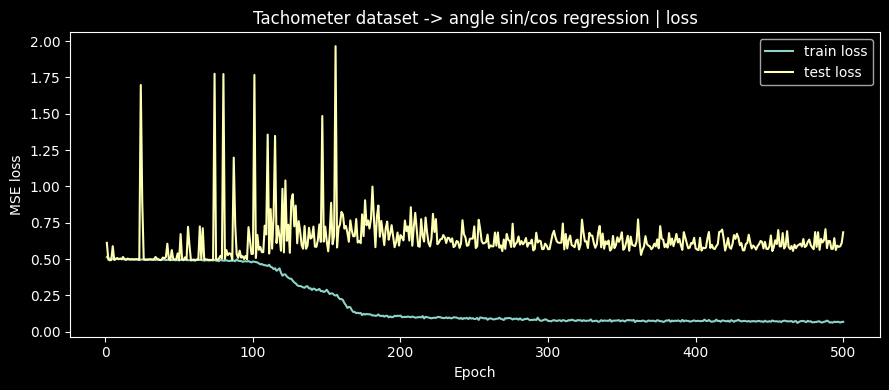

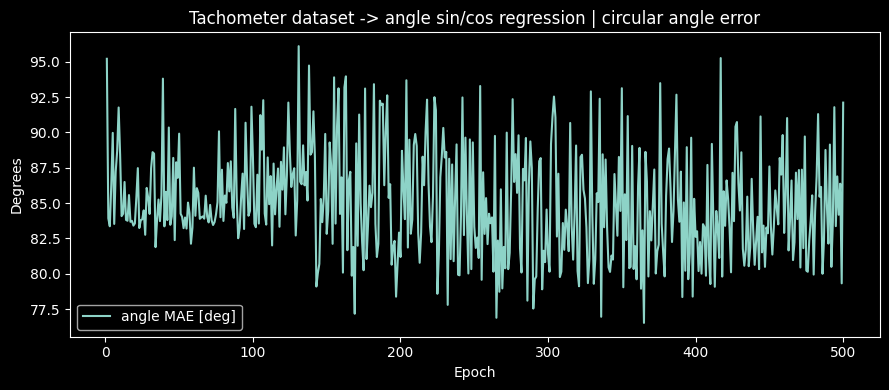

In [10]:
if RUN_TRAINING:
    tacho_history = fit_model(
        model=tacho_model,
        train_loader=tacho_train_loader,
        test_loader=tacho_test_loader,
        task="angle_sin_cos",
    )

    plot_training_history(
        tacho_history,
        "Tachometer dataset -> angle sin/cos regression",
    )
else:
    tacho_history = None
    print("Training skipped because RUN_TRAINING = False")


Epoch 001 | train loss=0.00385 | test loss=0.00004, MAE=0.00587, RMSE=0.00648
Epoch 002 | train loss=0.00008 | test loss=0.00002, MAE=0.00428, RMSE=0.00499
Epoch 003 | train loss=0.00004 | test loss=0.00001, MAE=0.00298, RMSE=0.00387
Epoch 004 | train loss=0.00003 | test loss=0.00001, MAE=0.00196, RMSE=0.00312
Epoch 005 | train loss=0.00002 | test loss=0.00001, MAE=0.00174, RMSE=0.00272
Epoch 006 | train loss=0.00001 | test loss=0.00001, MAE=0.00176, RMSE=0.00259
Epoch 007 | train loss=0.00001 | test loss=0.00001, MAE=0.00177, RMSE=0.00255
Epoch 008 | train loss=0.00001 | test loss=0.00001, MAE=0.00181, RMSE=0.00253
Epoch 009 | train loss=0.00001 | test loss=0.00001, MAE=0.00179, RMSE=0.00251
Epoch 010 | train loss=0.00001 | test loss=0.00001, MAE=0.00182, RMSE=0.00248
Epoch 011 | train loss=0.00001 | test loss=0.00001, MAE=0.00184, RMSE=0.00249
Epoch 012 | train loss=0.00001 | test loss=0.00001, MAE=0.00181, RMSE=0.00252
Epoch 013 | train loss=0.00001 | test loss=0.00001, MAE=0.00189,

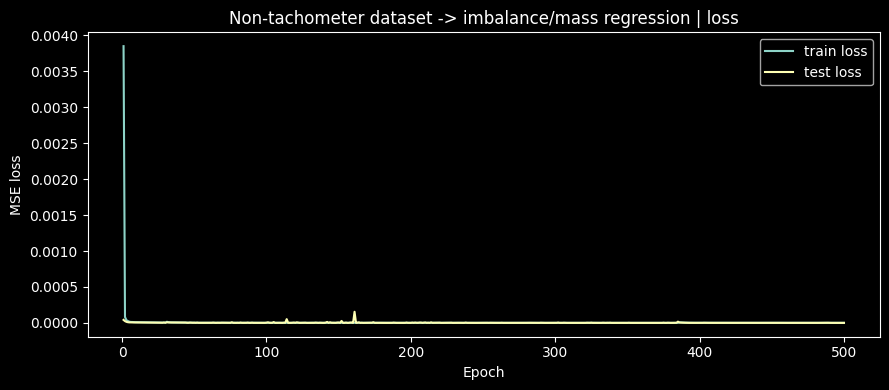

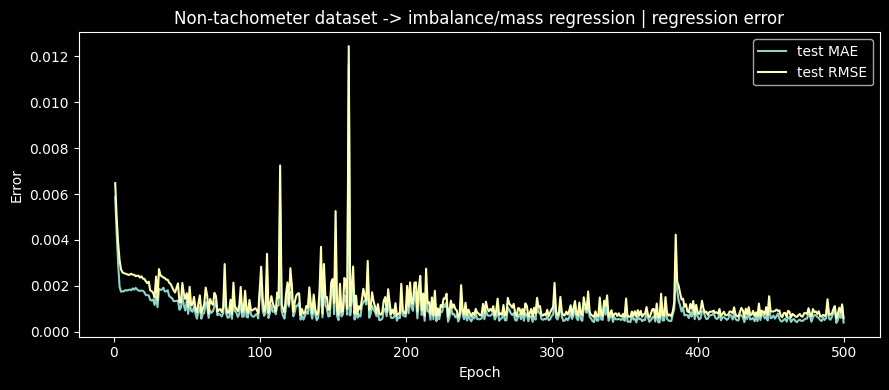

In [11]:
if RUN_TRAINING:
    non_tacho_history = fit_model(
        model=non_tacho_model,
        train_loader=non_tacho_train_loader,
        test_loader=non_tacho_test_loader,
        task="imbalance",
    )

    plot_training_history(
        non_tacho_history,
        "Non-tachometer dataset -> imbalance/mass regression",
    )
else:
    non_tacho_history = None
    print("Training skipped because RUN_TRAINING = False")


Tachometer angle regression:
{'mse': 0.6846131682395935, 'mae': 0.6946954727172852, 'rmse': 0.8274135589599609, 'angle_mae_deg': 92.10498809814453, 'loss': 0.6846131938795804}


C:\Users\adam0\AppData\Local\Temp\ipykernel_39368\1414862589.py:87: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\Projects\GitHub\Wywazanie\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


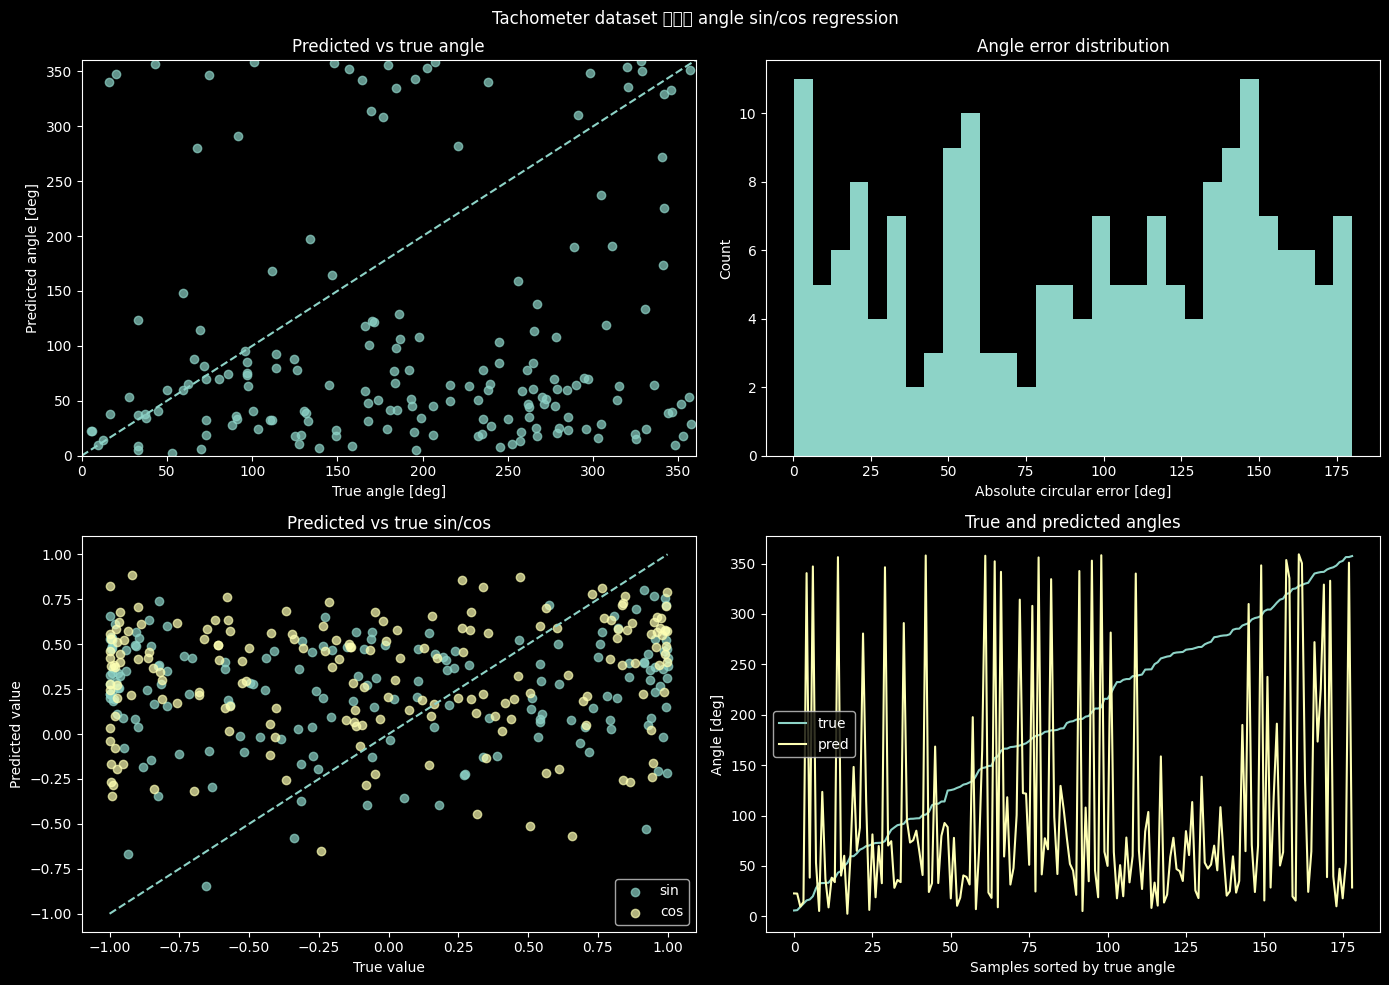

Non-tachometer imbalance/mass regression:
{'mse': 3.4775064250425203e-07, 'mae': 0.0003993565624114126, 'rmse': 0.0005897038499824703, 'loss': 3.477506268754628e-07}


C:\Users\adam0\AppData\Local\Temp\ipykernel_39368\1414862589.py:131: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


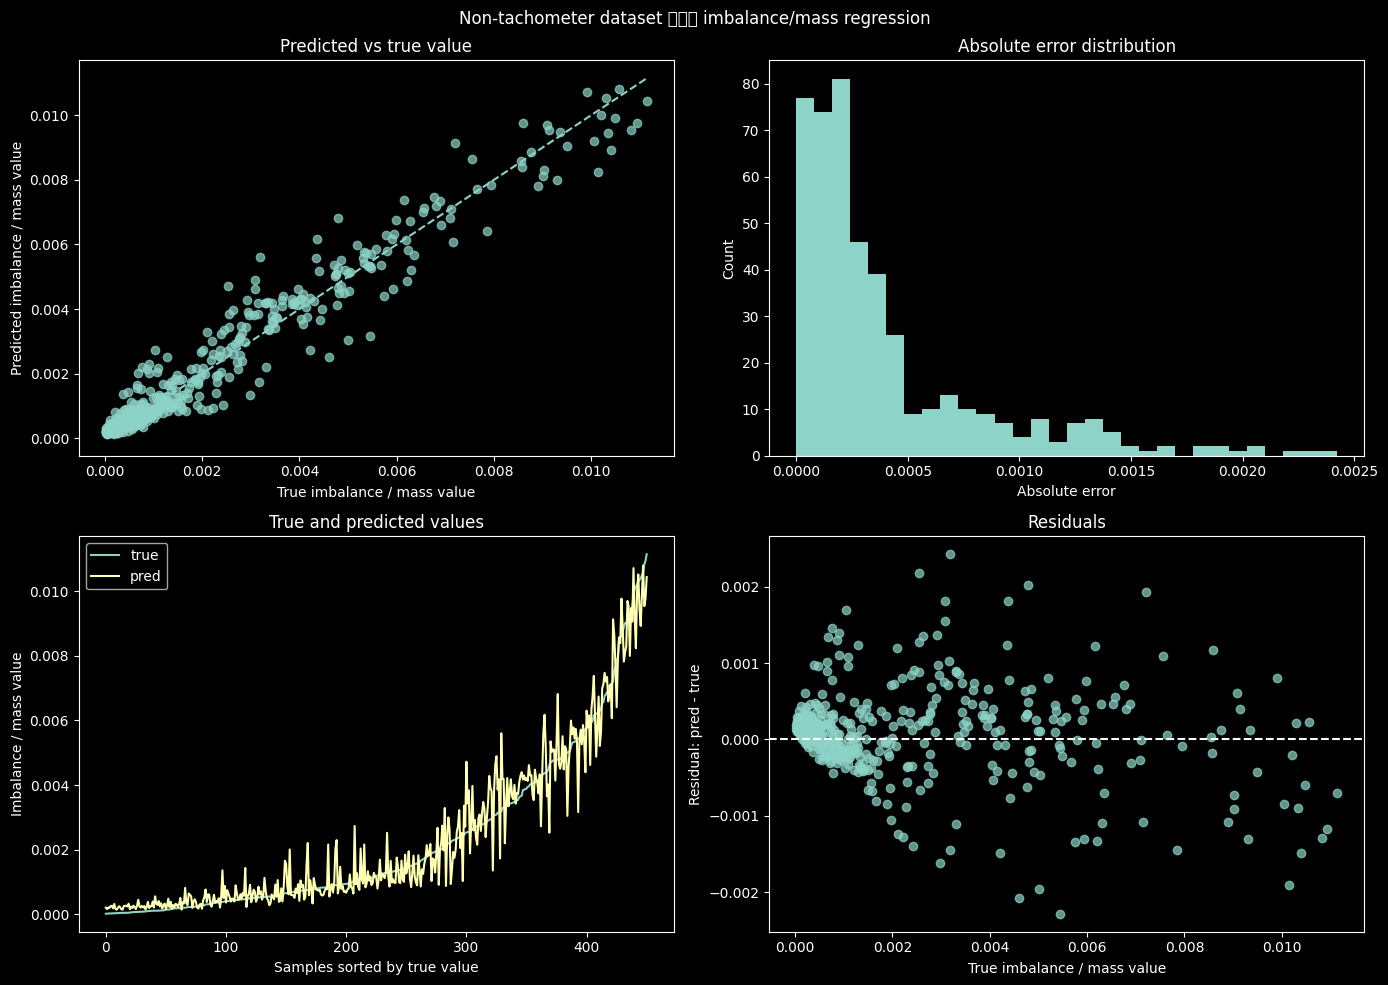

In [12]:
@torch.no_grad()
def prediction_table(model, dataset, loader, task, device=DEVICE):
    criterion = nn.MSELoss()
    metrics = evaluate(model, loader, criterion, device, task=task)

    rows = []

    for i, (y_true, y_pred) in enumerate(zip(metrics["y_true"], metrics["y_pred"])):
        row = {
            "sample_index": i,
            "y_true": y_true.tolist(),
            "y_pred": y_pred.tolist(),
        }

        if task == "angle_sin_cos":
            true_angle = np.arctan2(y_true[0], y_true[1])
            pred_angle = np.arctan2(y_pred[0], y_pred[1])

            diff = np.arctan2(
                np.sin(pred_angle - true_angle),
                np.cos(pred_angle - true_angle),
            )

            row.update({
                "true_angle_deg": float(np.degrees(true_angle) % 360),
                "pred_angle_deg": float(np.degrees(pred_angle) % 360),
                "angle_error_deg": float(abs(np.degrees(diff))),
                "true_sin": float(y_true[0]),
                "true_cos": float(y_true[1]),
                "pred_sin": float(y_pred[0]),
                "pred_cos": float(y_pred[1]),
            })

        else:
            row.update({
                "true_value": float(y_true[0]),
                "pred_value": float(y_pred[0]),
                "abs_error": float(abs(y_pred[0] - y_true[0])),
            })

        rows.append(row)

    return pd.DataFrame(rows), metrics


def plot_angle_regression_results(pred_table, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.scatter(pred_table["true_angle_deg"], pred_table["pred_angle_deg"], alpha=0.7)
    ax.plot([0, 360], [0, 360], linestyle="--")
    ax.set_xlabel("True angle [deg]")
    ax.set_ylabel("Predicted angle [deg]")
    ax.set_title("Predicted vs true angle")
    ax.set_xlim(0, 360)
    ax.set_ylim(0, 360)

    ax = axes[0, 1]
    ax.hist(pred_table["angle_error_deg"], bins=30)
    ax.set_xlabel("Absolute circular error [deg]")
    ax.set_ylabel("Count")
    ax.set_title("Angle error distribution")

    ax = axes[1, 0]
    ax.scatter(pred_table["true_sin"], pred_table["pred_sin"], alpha=0.7, label="sin")
    ax.scatter(pred_table["true_cos"], pred_table["pred_cos"], alpha=0.7, label="cos")
    ax.plot([-1, 1], [-1, 1], linestyle="--")
    ax.set_xlabel("True value")
    ax.set_ylabel("Predicted value")
    ax.set_title("Predicted vs true sin/cos")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.legend()

    ax = axes[1, 1]
    order = np.argsort(pred_table["true_angle_deg"].to_numpy())
    x = np.arange(len(order))

    ax.plot(x, pred_table["true_angle_deg"].to_numpy()[order], label="true")
    ax.plot(x, pred_table["pred_angle_deg"].to_numpy()[order], label="pred")
    ax.set_xlabel("Samples sorted by true angle")
    ax.set_ylabel("Angle [deg]")
    ax.set_title("True and predicted angles")
    ax.legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_imbalance_regression_results(pred_table, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.scatter(pred_table["true_value"], pred_table["pred_value"], alpha=0.7)

    min_val = min(pred_table["true_value"].min(), pred_table["pred_value"].min())
    max_val = max(pred_table["true_value"].max(), pred_table["pred_value"].max())

    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    ax.set_xlabel("True imbalance / mass value")
    ax.set_ylabel("Predicted imbalance / mass value")
    ax.set_title("Predicted vs true value")

    ax = axes[0, 1]
    ax.hist(pred_table["abs_error"], bins=30)
    ax.set_xlabel("Absolute error")
    ax.set_ylabel("Count")
    ax.set_title("Absolute error distribution")

    ax = axes[1, 0]
    order = np.argsort(pred_table["true_value"].to_numpy())
    x = np.arange(len(order))

    ax.plot(x, pred_table["true_value"].to_numpy()[order], label="true")
    ax.plot(x, pred_table["pred_value"].to_numpy()[order], label="pred")
    ax.set_xlabel("Samples sorted by true value")
    ax.set_ylabel("Imbalance / mass value")
    ax.set_title("True and predicted values")
    ax.legend()

    ax = axes[1, 1]
    residual = pred_table["pred_value"] - pred_table["true_value"]
    ax.scatter(pred_table["true_value"], residual, alpha=0.7)
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("True imbalance / mass value")
    ax.set_ylabel("Residual: pred - true")
    ax.set_title("Residuals")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


if RUN_TRAINING:
    tacho_pred_table, tacho_final_metrics = prediction_table(
        tacho_model,
        tacho_test_ds,
        tacho_test_loader,
        task="angle_sin_cos",
    )

    non_tacho_pred_table, non_tacho_final_metrics = prediction_table(
        non_tacho_model,
        non_tacho_test_ds,
        non_tacho_test_loader,
        task="imbalance",
    )

    print("Tachometer angle regression:")
    print({k: v for k, v in tacho_final_metrics.items() if k not in ("y_true", "y_pred")})

    plot_angle_regression_results(
        tacho_pred_table,
        "Tachometer dataset ﷿﷿﷿ angle sin/cos regression",
    )

    print("Non-tachometer imbalance/mass regression:")
    print({k: v for k, v in non_tacho_final_metrics.items() if k not in ("y_true", "y_pred")})

    plot_imbalance_regression_results(
        non_tacho_pred_table,
        "Non-tachometer dataset ﷿﷿﷿ imbalance/mass regression",
    )

else:
    print("Evaluation skipped because RUN_TRAINING = False")

In [13]:
MODEL_DIR = Path.cwd() / "Torch_Models"
MODEL_DIR.mkdir(exist_ok=True)

if RUN_TRAINING:
    torch.save(
        {
            "model_state_dict": tacho_model.state_dict(),
            "in_channels": tacho_train_ds.in_channels,
            "output_dim": 2,
            "target": "angle_sin_cos",
            "target_description": "[sin(angle), cos(angle)]",
            "component_names": tacho_train_ds.component_names,
        },
        MODEL_DIR / "tacho_angle_sincos_cnn_regressor.pt",
    )

    torch.save(
        {
            "model_state_dict": non_tacho_model.state_dict(),
            "in_channels": non_tacho_train_ds.in_channels,
            "output_dim": 1,
            "target": "imbalance_mass_value",
            "component_names": non_tacho_train_ds.component_names,
        },
        MODEL_DIR / "non_tacho_imbalance_cnn_regressor.pt",
    )

    print(f"Saved models to: {MODEL_DIR}")
else:
    print("Models not saved because RUN_TRAINING = False")


Saved models to: D:\Projects\GitHub\Wywazanie\Pipeline\Torch_Models
